# Week 1
A working Jupyter notebook that: (1) downloads a TESS 2-minute cadence light curve for Beta Pictoris (TIC 270577175) via Lightkurve, (2) plots raw flux vs. time, and (3) prints the FITS header keywords.

In [1]:
# Package imports
%matplotlib inline
import lightkurve as lk
import matplotlib.pyplot as plt
from astropy.io import fits

/Users/csavva/Documents/Repositories/astro-research/.venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


# Step 1
Download a TESS 2-min cadence light curve

In [2]:
search_result = lk.search_lightcurve('Beta Pictoris', author='SPOC')
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 04,2018,SPOC,120,270577175,0.0
1,TESS Sector 05,2018,SPOC,120,270577175,0.0
2,TESS Sector 06,2018,SPOC,120,270577175,0.0
3,TESS Sector 07,2019,SPOC,120,270577175,0.0
4,TESS Sector 32,2020,SPOC,120,270577175,0.0
5,TESS Sector 33,2020,SPOC,120,270577175,0.0
6,TESS Sector 34,2021,SPOC,120,270577175,0.0
7,TESS Sector 87,2024,SPOC,20,270577175,0.0
8,TESS Sector 87,2024,SPOC,120,270577175,0.0


In [3]:
search_result = lk.search_lightcurve(
    "TIC 270577175", mission="TESS", cadence="short", author="SPOC"
)
print(search_result)

if len(search_result) > 0:
    lc = search_result[0].download()
    lc

SearchResult containing 10 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 04 2018   SPOC     120   270577175      0.0
  1 TESS Sector 05 2018   SPOC     120   270577175      0.0
  2 TESS Sector 06 2018   SPOC     120   270577175      0.0
  3 TESS Sector 07 2019   SPOC     120   270577175      0.0
  4 TESS Sector 32 2020   SPOC     120   270577175      0.0
  5 TESS Sector 33 2020   SPOC     120   270577175      0.0
  6 TESS Sector 34 2021   SPOC     120   270577175      0.0
  7 TESS Sector 87 2024   SPOC     120   270577175      0.0
  8 TESS Sector 95 2025   SPOC     120   270577175      0.0
  9 TESS Sector 98 2025   SPOC     120   270577175      0.0


# Step 2
Plots of raw flux vs. time

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

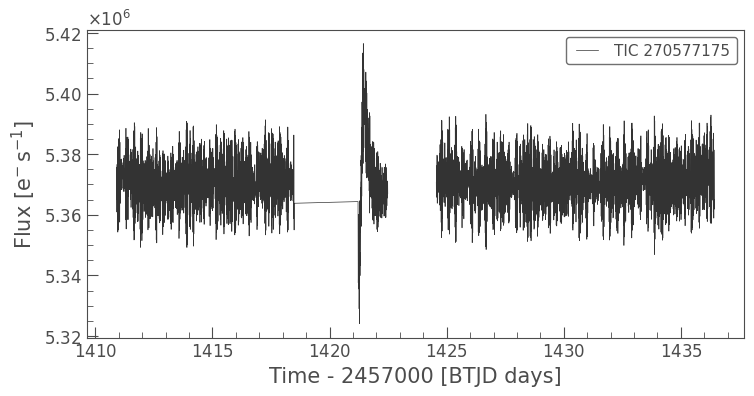

In [4]:
lc.plot()

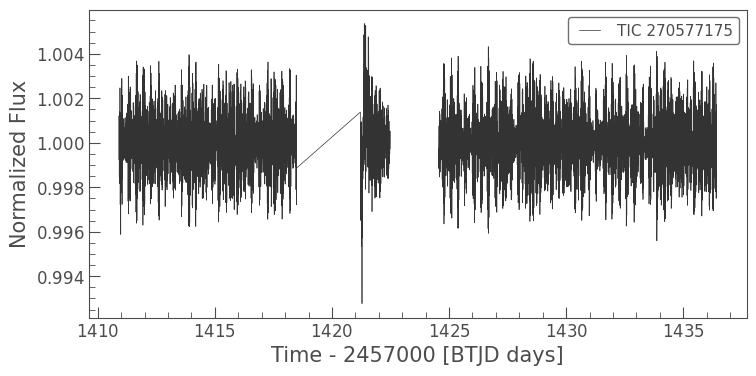

In [5]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();

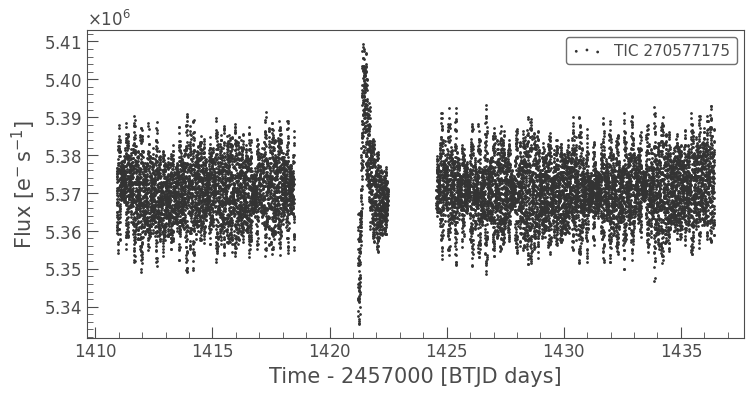

In [6]:
lc = lc.remove_nans().remove_outliers()
lc.scatter();

# Step 3
Print the FITS header keywords

In [7]:
lc.to_fits(path='beta-pictoris.fits', overwrite=True)

In [8]:
hdu = fits.open('beta-pictoris.fits')
hdu[0].header

SIMPLE  =                    T / conforms to FITS standards                     
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T / file contains extensions                       
NEXTEND =                    2 / number of standard extensions                  
EXTNAME = 'PRIMARY '           / name of extension                              
EXTVER  =                    1 / extension version number (not format version)  
ORIGIN  = 'Unofficial data product' / institution responsible for file          
DATE    = '2026-03-15'         / file creation date.                            
CREATOR = 'lightkurve.LightCurve.to_fits()' / pipeline job and program used t   
TELESCOP= 'TESS    '           / telescope                                      
INSTRUME=  / detector type                                                      
OBJECT  = '270577175'       